* step 1 : Loading Data and Sampling
* step 2 : EDA
* step 3 : Merging tables
* step 4 : Building a Joint Purchasing Matrix
* step 5 : Grouping Sections Using K-Means
* step 6 : Generating a Heatmap
* step 7 : create dashboard by power bi


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

* step 1 : Loading Data and Sampling

In [2]:
products = pd.read_csv(r'archive\products.csv')
aisles = pd.read_csv(r'archive\aisles.csv')
departments = pd.read_csv(r'archive\departments.csv')

orders = pd.read_csv(r'archive\orders.csv')
order_products_prior = pd.read_csv(r'archive\order_products__prior.csv')

sample_users = orders['user_id'].drop_duplicates().sample(frac=0.3, random_state=42)
sample_orders = orders[orders['user_id'].isin(sample_users)]
sample_order_products = order_products_prior[order_products_prior['order_id'].isin(sample_orders['order_id'])]

print(f" NO.sample data : {len(sample_order_products)} ")

 NO.sample data : 9818593 


* step 2 : EDA

C:\Users\lenovo\AppData\Local\Temp\ipykernel_20112\2840415218.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')


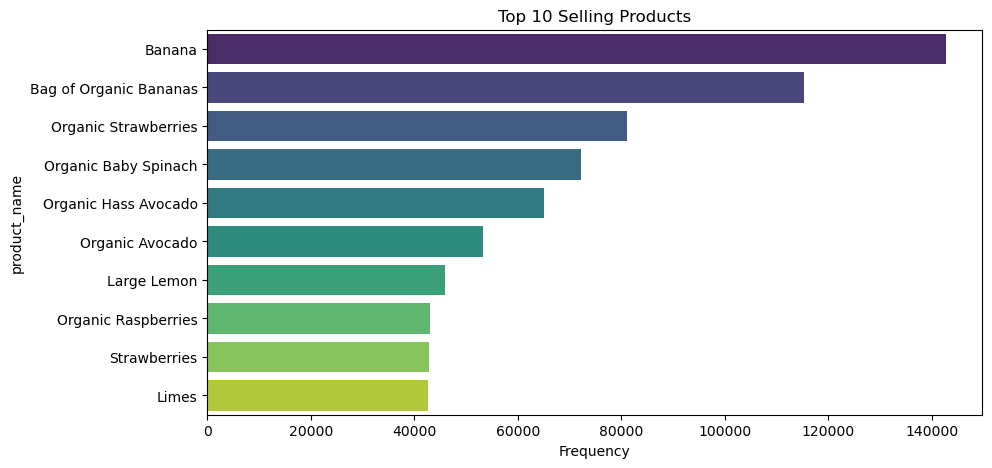

In [3]:
top_products = sample_order_products.merge(products, on='product_id')['product_name'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 10 Selling Products')
plt.xlabel('Frequency')
plt.show()
# 1. Top 10 Best-Selling Products

In [4]:
# 2. Department pairs most frequently purchased together (for shelf layout planning)
merged_data = sample_order_products.merge(products, on='product_id').merge(aisles, on='aisle_id')
basket_aisles = merged_data.groupby(['order_id', 'aisle'])['aisle'].count().unstack().fillna(0)

In [5]:
basket_aisles = (basket_aisles > 0).astype(int)


In [6]:
aisle_cooccurrence = basket_aisles.T.dot(basket_aisles)


In [7]:
np.fill_diagonal(aisle_cooccurrence.values, 0)


In [8]:
temp_matrix = aisle_cooccurrence.copy()
temp_matrix.index.name = 'Aisle_1'
temp_matrix.columns.name = 'Aisle_2'

temp_matrix = temp_matrix.reset_index()

aisle_pairs = temp_matrix.melt(id_vars='Aisle_1', var_name='Aisle_2', value_name='Count')

aisle_pairs = aisle_pairs[aisle_pairs['Aisle_1'] != aisle_pairs['Aisle_2']]


In [9]:
# Extracting the top 10 pairs

top_aisle_pairs = aisle_pairs.sort_values(by='Count', ascending=False).head(10)
print("Top Category Pairs bought together:\n", top_aisle_pairs)

Top Category Pairs bought together:
                           Aisle_1                     Aisle_2   Count
7152                 fresh fruits            fresh vegetables  309161
6753             fresh vegetables                fresh fruits  309161
13182                fresh fruits  packaged vegetables fruits  263430
6798   packaged vegetables fruits                fresh fruits  263430
7200   packaged vegetables fruits            fresh vegetables  228212
13185            fresh vegetables  packaged vegetables fruits  228212
17872                fresh fruits                      yogurt  182040
6833                       yogurt                fresh fruits  182040
6783                         milk                fresh fruits  159953
11172                fresh fruits                        milk  159953


* step 3 : Merging tables

In [10]:
full_merged = merged_data.merge(departments, on='department_id', how='left')


In [11]:
full_merged = full_merged[[
    "order_id",
    "product_id",
    "product_name",
    "aisle_id",
    "aisle",
    "department_id",
    "department",
    "add_to_cart_order",
    "reordered"
]]

In [12]:
full_merged.head()


,order_id,product_id,product_name,aisle_id,aisle,department_id,department,add_to_cart_order,reordered
0,6,40462,Cleanse,31,refrigerated,7,beverages,1,0
1,6,15873,Dryer Sheets Geranium Scent,75,laundry,17,household,2,0
2,6,41897,Clean Day Lavender Scent Room Freshener Spray,101,air fresheners candles,17,household,3,0
3,22,23909,2% Reduced Fat Milk,84,milk,16,dairy eggs,1,1
4,22,22754,Butter Top White Bread,112,bread,3,bakery,2,1


In [13]:
full_merged.to_csv('merged_for_powerbi.csv', index=False)
print("File saved successfully to Power BI")

File saved successfully to Power BI


* step 4 : Building a Joint Purchasing Matrix

In [14]:
basket_matrix = merged_data.groupby(['order_id', 'aisle'])['aisle'].count().unstack().fillna(0)
basket_matrix = basket_matrix.map(lambda x: 1 if x > 0 else 0)

co_purchase_matrix = basket_matrix.T.dot(basket_matrix)
np.fill_diagonal(co_purchase_matrix.values, 0) # تصفير القطر

co_purchase_matrix.head()

aisle,air fresheners candles,asian foods,baby accessories,baby bath body care,baby food formula,bakery desserts,baking ingredients,baking supplies decor,beauty,beers coolers,...,spreads,tea,tofu meat alternatives,tortillas flat bread,trail mix snack mix,trash bags liners,vitamins supplements,water seltzer sparkling water,white wines,yogurt
aisle,,,,,,,,,,,,,,,,,,,,,
air fresheners candles,0,262,37,40,153,80,558,77,69,84,...,393,498,122,327,45,224,125,1209,91,1097
asian foods,262,0,187,145,2387,499,5756,479,118,361,...,4860,3614,4498,4007,415,520,821,8631,269,13297
baby accessories,37,187,0,53,601,41,312,35,15,12,...,334,234,146,239,19,72,76,758,7,1063
baby bath body care,40,145,53,0,448,28,323,33,22,14,...,320,180,92,236,29,80,86,561,11,963
baby food formula,153,2387,601,448,0,530,4271,320,97,170,...,5369,2616,2105,3846,594,604,731,10070,112,22203


* step 5 : Grouping Sections Using K-Means

In [15]:
# Scaling before K-Means
scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(co_purchase_matrix)

In [16]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_matrix)

c:\Users\lenovo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\lenovo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\lenovo\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\lenovo\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^

In [17]:
# Adding the group to each section
aisle_clusters = pd.DataFrame({
    'Aisle': co_purchase_matrix.index,
    'Cluster': clusters
})

In [18]:
# This is the "Shelf Plan" that the category manager can act upon.
shelf_plan = aisle_clusters.sort_values(by='Cluster')
print("=== Shelf Space Allocation Plan ===")
print(shelf_plan.to_string(index=False))

# saved shelf_plan
shelf_plan.to_csv('shelf_plan.csv', index=False)

=== Shelf Space Allocation Plan ===
                        Aisle  Cluster
                  asian foods        0
            baby food formula        0
            body lotions soap        0
                   buns rolls        0
            cleaning products        0
                       coffee        0
      canned fruit applesauce        0
   doughs gelatins bake mixes        0
                 food storage        0
         energy sports drinks        0
                 frozen pizza        0
      frozen vegan vegetarian        0
              dish detergents        0
                      granola        0
      grains rice dried goods        0
                          tea        0
             packaged produce        0
         pickled goods olives        0
                popcorn jerky        0
              poultry counter        0
               prepared meals        0
       preserved dips spreads        0
       tofu meat alternatives        0
      salad dressing topping

* step 6 : Generating a Heatmap


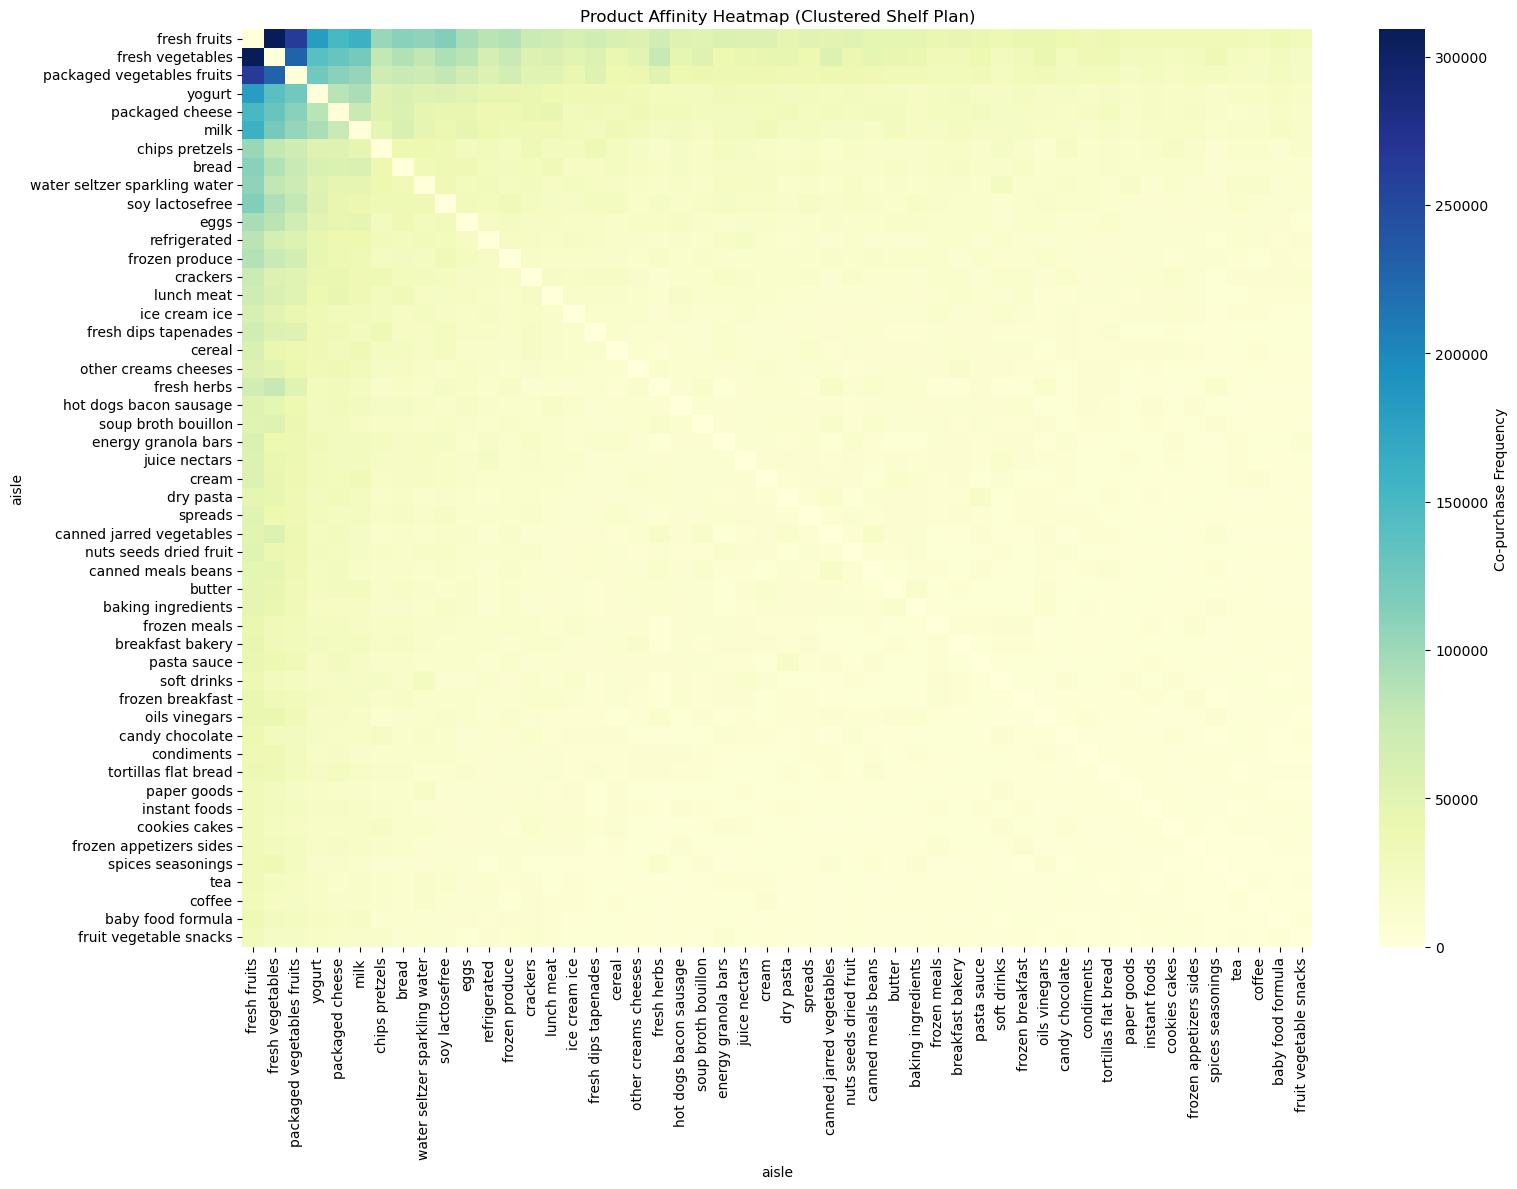

In [19]:
ordered_aisles = shelf_plan['Aisle'].values
ordered_matrix = co_purchase_matrix.loc[ordered_aisles, ordered_aisles]

plt.figure(figsize=(16, 12))
top_50_aisles = ordered_matrix.sum(axis=1).sort_values(ascending=False).head(50).index
heatmap_data = ordered_matrix.loc[top_50_aisles, top_50_aisles]

sns.heatmap(heatmap_data, cmap="YlGnBu", cbar_kws={'label': 'Co-purchase Frequency'})
plt.title('Product Affinity Heatmap (Clustered Shelf Plan)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()